<a href="https://colab.research.google.com/github/juanitapinedaguti/Integracion-de-Datos-y-Prospectiva/blob/main/Credibilidad_GymPulse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 1 - Caracterización de variables aleatorias

## Caso de estudio

FitBalance Gym es una cadena ficticia de gimnasios que busca analizar el riesgo económico relacionado con la cancelación de membresías.

Frecuencia: indica el número de clientes que cancelan su membresía diariamente (clientes/día).

Severidad: representa el ingreso promedio que el gimnasio deja de recibir por cada cliente que cancela (COP/cliente).

Distribución de pérdidas: resulta de multiplicar la frecuencia por la severidad y permite estimar la pérdida económica diaria causada por las cancelaciones.

## 1. Librerías


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Integracion de datos/Reto_1_Clientes_Gimnasio.xlsx"

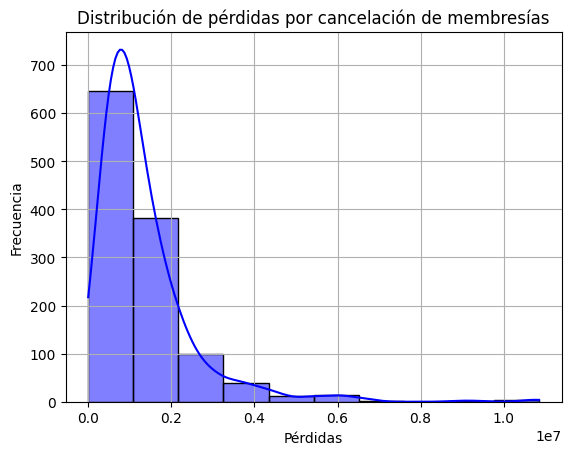

In [ ]:
df = pd.read_excel(path, sheet_name='Datos')
df.head()

Freq = pd.to_numeric(df.iloc[:,5], errors='coerce')
Sev = pd.to_numeric(df.iloc[:,6], errors='coerce')
LDA = Freq * Sev

plt.figure()
sns.histplot(LDA, color='blue', bins=10, kde=True)
plt.title('Distribución de pérdidas por cancelación de membresías')
plt.xlabel('Pérdidas')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

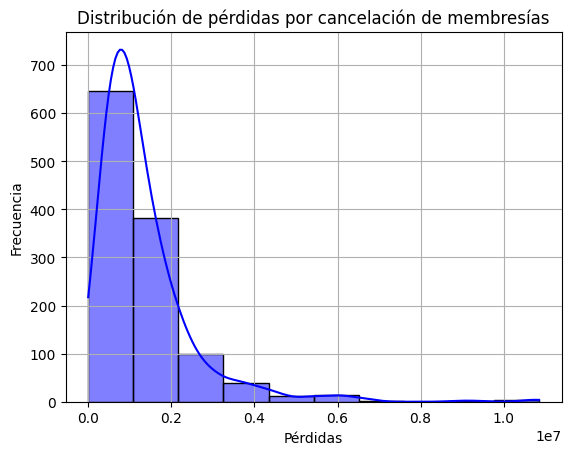

In [ ]:
df = pd.read_excel(path, sheet_name='Datos')
df.head()

Freq = pd.to_numeric(df.iloc[:,5], errors='coerce')
Sev = pd.to_numeric(df.iloc[:,6], errors='coerce')
LDA = Freq * Sev

plt.figure()
sns.histplot(LDA, color='blue', bins=10, kde=True)
plt.title('Distribución de pérdidas por cancelación de membresías')
plt.xlabel('Pérdidas')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

Se procede con la construcción del histograma de frecuencias

In [ ]:
NI = 10 # Número de intervalos
counts, Limits = np.histogram(LDA, bins=NI) # Agrupar los datos
LI = Limits[:-1] # Límite inferior
LS = Limits[1:] # Límite superior
fi = counts / sum(counts) # Porcentaje de datos por intervalo
MC = (LI + LS) / 2 # Marca de clase

histogram_data = pd.DataFrame({
    'LI': LI,
    'LS': LS,
    'ND': counts,
    'fi': fi,
    'MC': MC
})
display(histogram_data)

,LI,LS,ND,fi,MC
0,0.000000e+00,1.085172e+06,647,0.539167,5.425862e+05
1,1.085172e+06,2.170345e+06,382,0.318333,1.627759e+06
2,2.170345e+06,3.255517e+06,100,0.083333,2.712931e+06
3,3.255517e+06,4.340690e+06,38,0.031667,3.798104e+06
4,4.340690e+06,5.425862e+06,12,0.010000,4.883276e+06
5,5.425862e+06,6.511035e+06,14,0.011667,5.968449e+06
6,6.511035e+06,7.596207e+06,2,0.001667,7.053621e+06
7,7.596207e+06,8.681380e+06,0,0.000000,8.138794e+06
8,8.681380e+06,9.766552e+06,2,0.001667,9.223966e+06
9,9.766552e+06,1.085172e+07,3,0.002500,1.030914e+07


Medidas de tendencia central y dispersión

In [ ]:
np.set_printoptions(suppress=True)

# Media
U = np.sum(MC * fi)
print(f"La media de las pérdidas es: {U:.2f}")

# Varianza
varc = np.sum((MC - U)**2 * fi)
print(f"La varianza es: {varc:.2f}")

# Intervalo de variación de las pérdidas
sigma = np.sqrt(varc)
print(f"El límite inferior es: {U - 2*sigma:.2f}")
print(f"El límite superior es: {U + 2*sigma:.2f}")

# Coeficiente de asimetría
cas = np.sum(((MC - U)**3) * fi) / (sigma**3)
print(f"El coeficiente de asimetría es: {cas:.2f}")

# Coeficiente de curtosis
cur = np.sum(((MC - U)**4) * fi) / (sigma**4)
print(f"El coeficiente de curtosis es: {cur:.2f}")

La media de las pérdidas es: 1328431.99
La varianza es: 1452077288350.20
El límite inferior es: -1081611.40
El límite superior es: 3738475.38
El coeficiente de asimetría es: 2.86
El coeficiente de curtosis es: 15.76


## 5. Medidas solicitadas

In [ ]:
media = np.sum(MC * fi)
varianza = np.sum((MC - media)**2 * fi)
desviacion = np.sqrt(varianza)
asimetria = np.sum((MC - media)**3 * fi) / desviacion**3
curtosis = np.sum((MC - media)**4 * fi) / desviacion**4

resultados = pd.DataFrame({
    "Medida": ["Media", "Varianza", "Desviación estándar", "Asimetría", "Curtosis"],
    "Resultado": [media, varianza, desviacion, asimetria, curtosis]
})

resultados

,Medida,Resultado
0,Media,1.328432e+06
1,Varianza,1.452077e+12
2,Desviación estándar,1.205022e+06
3,Asimetría,2.859580e+00
4,Curtosis,1.575845e+01


In [ ]:
def MedidasDTC(Xi,NI):

    plt.figure()
    counts,Limits=np.histogram(LDA,bins=NI) # Se agrupan los datos en 10 intervalos
    LI=Limits[:-1] # Limites inferiores del histograma
    LS=Limits[1:] # Limites superiores del histograma
    fi=counts/sum(counts) # Porcentaje de datos por intervalo
    MC=(LI+LS)/2 # Marca de clase
    # Eliminar notación científica
    np.set_printoptions(suppress=True)

    plt.show()

    df=pd.DataFrame(np.column_stack((LI,LS,counts,fi,MC)))
    df.columns=['Limite Inferior','Limite Superior','ND','fi', 'MC']
    display



## Análisis de resultados

Los resultados obtenidos permiten observar el efecto que tiene el tamaño de la muestra sobre la representación de la distribución original de pérdidas. Para esto se compararon los datos originales con dos muestras, una de 1.000 y otra de 10.000 observaciones, evaluando los cambios en la media, la varianza, la asimetría y la curtosis.

En primer lugar, la **media** presenta un comportamiento cada vez más cercano al valor original a medida que aumenta el tamaño de la muestra. Con 1.000 observaciones se obtiene una diferencia aproximada del 3,74 %, mientras que con 10.000 observaciones esta diferencia disminuye hasta aproximadamente el 0,45 %. Esto muestra que la muestra de mayor tamaño representa con mayor precisión el nivel promedio de las pérdidas.

La **varianza** presenta un comportamiento similar. Con la muestra de 1.000 observaciones existe una diferencia aproximada del 4,22 % frente a los datos originales, mientras que con 10.000 observaciones la diferencia disminuye hasta aproximadamente el 0,09 %. Este resultado indica que la muestra de mayor tamaño logra conservar de manera mucho más precisa la dispersión existente en la distribución original. En otras palabras, no solamente se aproxima mejor al promedio de las pérdidas, sino también a la forma en que estas varían alrededor de dicho promedio.

En cuanto a la **asimetría**, los resultados mantienen valores positivos tanto en los datos originales como en las dos muestras. Esto permite identificar una distribución con una marcada inclinación hacia la derecha, indicando que la mayoría de las observaciones se encuentran concentradas en niveles de pérdida relativamente menores, mientras que existe un grupo más reducido de observaciones con pérdidas considerablemente mayores. Esta característica resulta importante para el análisis del riesgo, ya que demuestra que el comportamiento de las pérdidas no puede comprenderse únicamente a partir de su valor promedio.

Además, la muestra de 10.000 observaciones presenta una asimetría más cercana a la distribución original que la muestra de 1.000. Esto demuestra nuevamente que un mayor tamaño de muestra permite representar mejor no solo el promedio y la dispersión de los datos, sino también la forma que presenta la distribución.

Por otra parte, la **curtosis** es la medida que presenta las mayores diferencias durante el proceso de muestreo. Con 1.000 observaciones la diferencia frente al valor original es aproximadamente del 9,34 %, mientras que con 10.000 disminuye hasta cerca del 2,94 %. Esto permite observar que las características asociadas con la concentración de los datos y la presencia de valores extremos son más sensibles al tamaño de la muestra que medidas como la media o la varianza.

Al comparar de manera general ambos tamaños de muestra, se observa una tendencia clara: **al aumentar el número de observaciones, las medidas estadísticas se aproximan a las características de la distribución original**. Esta mejora es especialmente evidente en la media y la varianza, aunque también se presenta en la asimetría y la curtosis.

Desde la perspectiva del problema analizado, este comportamiento es relevante porque la distribución presenta una alta variabilidad y una asimetría positiva. Esto significa que existen pérdidas que pueden alejarse considerablemente del comportamiento promedio. Por esta razón, para comprender adecuadamente el riesgo no resulta suficiente analizar únicamente la media; también es necesario estudiar la dispersión y la forma de la distribución.

En conclusión, **la muestra de 10.000 observaciones presenta una representación más precisa y estable de los datos originales que la muestra de 1.000 observaciones**. Los resultados muestran que aumentar el tamaño de la muestra reduce las diferencias en las medidas estadísticas analizadas y permite conservar con mayor precisión las características de la distribución original. Esto demuestra la importancia del tamaño de la muestra cuando se busca realizar una estimación confiable del comportamiento de las pérdidas y utilizar los resultados como apoyo para la toma de decisiones.



# Teoría de la credibilidad

En esta sección se evalúa la credibilidad de la **base interna de FitBalance Gym** frente a la **base externa de GymPulse**. Se mantiene la metodología trabajada en clase: estimación del error de los datos internos, cálculo de la varianza ponderada (EPV), media hipotética ponderada, VHM y nivel de credibilidad asignado a cada fuente de información.


In [ ]:
# ============================================================
# TEORÍA DE LA CREDIBILIDAD
# Base observada/interna: FitBalance Gym
# Base externa: GymPulse
# ============================================================

# ------------------------------------------------------------
# 1. DATOS INTERNOS / OBSERVADOS - FITBALANCE GYM
# ------------------------------------------------------------

# Se reutiliza la misma base interna cargada al inicio del notebook
path_interno = "/content/drive/MyDrive/Integracion de datos/Reto_1_Clientes_Gimnasio.xlsx"

XDO = pd.read_excel(path_interno, sheet_name="Datos")

# Frecuencia y severidad de la base interna
Freq_o = pd.to_numeric(XDO.iloc[:, 5], errors="coerce")
Sev_o  = pd.to_numeric(XDO.iloc[:, 6], errors="coerce")

# Distribución agregada de pérdidas observadas
LDA_o = (Freq_o * Sev_o).dropna()

ND = len(LDA_o)
uo = np.mean(LDA_o)
sigmao = np.std(LDA_o)

print("BASE INTERNA - FITBALANCE GYM")
print("Número de datos:", ND)
print("Media:", uo)
print("Desviación estándar:", sigmao)

# ------------------------------------------------------------
# 2. INTERVALO Y ERROR DE LOS DATOS INTERNOS
# ------------------------------------------------------------

print("\nIntervalo aproximado de los datos internos al 95%:")
print("Límite inferior:", uo - 2*sigmao)
print("Límite superior:", uo + 2*sigmao)

# Parámetros utilizados en el ejercicio de clase
z = 1.96
P = 0.95

E = z * np.sqrt((P * (1 - P)) / ND)

print("\nError en el cálculo de los datos internos:", E)

print("\nIntervalo de la media considerando el error:")
print("Media menos error:", uo - E)
print("Media más error:", uo + E)
print("Desfase:", (uo + E) - (uo - E))


# ------------------------------------------------------------
# 3. DATOS EXTERNOS - GYMPULSE
# ------------------------------------------------------------

path_externo = "/content/drive/MyDrive/Integracion de datos/Base_de_Datos_GymPulse_Externa.xlsx"

XDE = pd.read_excel(path_externo, sheet_name=0)

# Se utilizan las variables de GymPulse trabajadas en la integración
Freq_e = pd.to_numeric(
    XDE["Frecuencia_Cancelaciones_Dia"],
    errors="coerce"
)

Sev_e = pd.to_numeric(
    XDE["Severidad_COP_Cliente"],
    errors="coerce"
)

LDA_e = (Freq_e * Sev_e).dropna()

NDe = len(LDA_e)
ue = np.mean(LDA_e)
sigmae = np.std(LDA_e)

print("\nBASE EXTERNA - GYMPULSE")
print("Número de datos:", NDe)
print("Media:", ue)
print("Desviación estándar:", sigmae)


# ------------------------------------------------------------
# 4. TEORÍA DE CREDIBILIDAD
# ------------------------------------------------------------

# Varianza ponderada (EPV)
EPV = (
    ND * sigmao**2 +
    NDe * sigmae**2
) / (ND + NDe)

print("\nLa ponderación de las varianzas (EPV) es:", EPV)

# Media hipotética: ponderado de las medias
uh = (
    ND * uo +
    NDe * ue
) / (ND + NDe)

print("La media hipotética ponderada es:", uh)

# VHM: varianza de las medias hipotéticas
VHM = (
    (ND / (ND + NDe)) * uo**2 +
    (NDe / (ND + NDe)) * ue**2
) - uh**2

print("La VHM es:", VHM)

# Credibilidad
if VHM > 0:
    Cr = ND / (ND + (EPV / VHM))

    print("\nLa credibilidad de la base interna FitBalance es:", Cr * 100, "%")
    print("La credibilidad de la base externa GymPulse es:", (1 - Cr) * 100, "%")
else:
    Cr = np.nan
    print("\nNo es posible calcular la credibilidad porque VHM es igual a 0.")


# ------------------------------------------------------------
# 5. RESUMEN DE RESULTADOS
# ------------------------------------------------------------

resumen_credibilidad = pd.DataFrame({
    "Indicador": [
        "Número de datos internos",
        "Número de datos externos",
        "Media FitBalance",
        "Media GymPulse",
        "Desviación FitBalance",
        "Desviación GymPulse",
        "EPV",
        "Media hipotética",
        "VHM",
        "Credibilidad FitBalance (%)",
        "Credibilidad GymPulse (%)"
    ],
    "Resultado": [
        ND,
        NDe,
        uo,
        ue,
        sigmao,
        sigmae,
        EPV,
        uh,
        VHM,
        Cr * 100 if not np.isnan(Cr) else np.nan,
        (1 - Cr) * 100 if not np.isnan(Cr) else np.nan
    ]
})

display(resumen_credibilidad)


BASE INTERNA - FITBALANCE GYM
Número de datos: 1200
Media: 1324055.9862469372
Desviación estándar: 1190021.1775745244

Intervalo aproximado de los datos internos al 95%:
Límite inferior: -1055986.3689021117
Límite superior: 3704098.3413959863

Error en el cálculo de los datos internos: 0.012331396244275563

Intervalo de la media considerando el error:
Media menos error: 1324055.9739155408
Media más error: 1324055.9985783335
Desfase: 0.024662792682647705

BASE EXTERNA - GYMPULSE
Número de datos: 1200
Media: 338441.4969833333
Desviación estándar: 473922.9809544293

La ponderación de las varianzas (EPV) es: 820376697476.295
La media hipotética ponderada es: 831248.7416151352
La VHM es: 242858980361.58875

La credibilidad de la base interna FitBalance es: 99.7192905182114 %
La credibilidad de la base externa GymPulse es: 0.2807094817885991 %


,Indicador,Resultado
0,Número de datos internos,1.200000e+03
1,Número de datos externos,1.200000e+03
2,Media FitBalance,1.324056e+06
3,Media GymPulse,3.384415e+05
4,Desviación FitBalance,1.190021e+06
5,Desviación GymPulse,4.739230e+05
6,EPV,8.203767e+11
7,Media hipotética,8.312487e+05
8,VHM,2.428590e+11
9,Credibilidad FitBalance (%),9.971929e+01
